# 🌍💹 NOTEBOOK DE DORIAN LE STATISTICIEN 	🌍💹

## === GUIDE des fonctions du module local datalake === 

from DATALAKE.data import *

**data = data_download_gmd("country")** -> Telechargement des données liés à un pays via global_macro_dataset (BD publique)

**data = data_download_fred("indicator"** : str, "start" : str , "end" : str) -> Telechargement d'un indicateur via la FRED (BD publique)

**data_storing(data : dataframe, "nom_fichier" : str)** -> Range un dataframe "data" dans le DATALAKE en parquet, que vous venez de télécharger d'internet 

**data = import_parquet("file_name" : str)** -> importe un dataframe du DATALAKE dans votre file cible (notebook ou .py)

**which_parquet()** -> Vous renvoie une liste de l'ensemble des parquets dispo dans le DATALAKE

In [1]:
from outils_eda import *
from DATALAKE.data import *


path = "../../DATALAKE/PARQUET_FOLDER/main_cleaned.parquet"
df = pd.read_parquet(path)

## Corrélations potentielles et mise en perspective historique

### **Gold Standard**

#### Correlation between interest rate and exchange rate

Thanks to the gold standard era, I think we could expect no correlation between the interest rates and the exchange rates because of the quick adjustments that the CB had to do. For example, if UK is in crisis and their balance sheet is negative (they import more than they export) it means that to keep their exchange rate stable (mandatory under gold standard) they had to buy back their excess of money in the market with their gold to make the demand of UK money decrease and so make the UK money appreciate again. That movement makes the money supply shrinks meaning that the interest rates had to increase (to match demand and supply). So basically the chain reaction would be : **negative balance sheet → buy back UK currency → shrinks UK currency supply → increase interest rates.** That’s a sort of negative spiral that explain why gold standard is not a really good model (because you don’t have any sovereignty to apply the monetary policy that you want (basically here UK increased interest rates even if they were in a bad situation which makes a recession happen,, that’s exactly what Nixon did during the interwar which causes depression).

The question is : does that relationship appear in the data meaning do we have correlation and no correlation appearing in the data (because of the annually frame that we chose)

#### Correlation between interest rate and GDP

Because of the previous explanation, I would expect a negative correlation between gdp but once again, because of granularity, we don’t really know if it will appear in the data. 

#### Correlation between interest rate and inflation

I think that we should expect no correlation between those two simply because interest rates could not be used to calm or increase inflation (ref. first explanation). 

### **Bretton woods**

In the Bretton Woods era, all the currencies (including the pound) were pegged to the US dollar itself pegged to the gold. The main difference is that during that era, the countries were able to devalue their money for a momment during a crisis and to ask for fund (the IMF) if it was in a bad position. The other main difference that is important for our analysis is that countries had possibilities to limit capital flows.

#### Correlation between interest rate and exchange rate

In the gold standard era we expect the interest rate to move frequently each time the country has a positive or negative balance sheet. In the bretton woods it’s slightly different because the countries had the possibility to limit capital flows so we expect the interest rates being more stable during that period. The mechanism is the following : if your balance sheet is negative you have two choices to keep your currency stable :

- You buy back your excess currency (like in the gold era) with gold
- You limit the capital flows : meaning that you block people from buying your currency. If we take the same example as before, UK is in crisis,, negative balance sheet so there is too much pound on the market which should devalue the pound. The solution was not to buyback the currency but rather say “no investors you are not able to buy that excess of pounds (limit capital outflows because people have to keep their pounds) → the arbitrage can not take place and the money is not devaluated. That limitation makes us expect that the interest rate was more stable in that period because they had another possibility to move from devaluation.

#### Correlation between interest rate and GDP

Because of that limitation of capital outflow, UK has the possibility to keep the interest rate low while keeping their currency stable. It means that in the data, we should see an increase of GDP compared to before and also a correlation that is negative (low interest → high GDP). The question is when is the impact (lagged or not). 

But the UK could not keep that capital outflow limitation long (until crisis in 1967) because people were finding ways to sell their pounds which made the devaluation occur anyway. At the same time UK was facing inflation because of that strong increase in the GDP. This means that at the same time the pound was depreciating and exports were lower. The balance sheet was even lower so the only solution was to make the pound devaluate. 

#### Correlation between interest rate and inflation

We can expect to see a better correlation between interest rates and inflation because of the fact that capital outflows limitation where enabling UK to have a slightly better monetary policy and be able to calm inflation in case they needed. However, it maybe does not appear in the data as the UK mainly decided to make the economy grow without really looking at inflation keeping their interest rates low. 

### **Floating rates**

#### Correlation between interest rate and exchange rate

We clearly expect a positive correlation between exchange rate and interest rate. The mechanism is the following : if my interest rate had increased, everybody wants to buy my money which makes it scarcer on the market so the money appreciates immediately. Aside this, because of that quick appreciation, the UIP predicts that the expected future appreciation rate will decrease because the money already appreciated. 

#### Correlation between interest rate and GDP

We expect our “classic” correlation meaning that when interest grows GDP calms and vice-versa. The question is when does that effect take place (important to lag)

#### Correlation between interest rate and inflation

Same as before : the question is more when is the effect taking place (lags) rather than knowing if there is a correlation (there will normally be a negative one but be careful because in t→t it could be positive ie the CB adjust their rates when there is inflation).

## Analyse univariée

### All variables

### Nominal GDP (en millions des livres)

In [2]:
print(f"{df["gdp_nominal"].describe()}\n")

histogram(df, 'gdp_nominal')

time_evo(df, 'gdp_nominal')

time_evo_clean(df, 'gdp_nominal')

count    1.760000e+02
mean     3.447202e+05
std      6.578334e+05
min      5.461955e+02
25%      1.476830e+03
50%      5.587566e+03
75%      2.950620e+05
max      2.745120e+06
Name: gdp_nominal, dtype: float64



On voit clairement une trend que l'on va devoir contrôler en stationnarisant. La chose à noter également (et peut être à expliquer) est que le point d'inflexion se trouve vers les années 70 (personnellement je m'attendais à plus tôt). Selon moi ceci peut être expliqué par deux facteurs : le capitalisme et l'inflation.

### Expected inflation (en %)

In [3]:
print(f"{df["expected_inflation"].describe()}\n")

histogram(df, 'expected_inflation')

time_evo(df, 'expected_inflation')

count    177.000000
mean       2.410551
std        5.117969
min      -14.000000
25%        0.007000
50%        1.600000
75%        3.842049
max       25.200000
Name: expected_inflation, dtype: float64



Ce graphe est assez interéssant car il permet de comprendre l'incertitude autour de l'inflation. Les périodes durant lesquelles l'inflation anticipée était élevée sont les mêmes que les périodes de point d'inflexion des covariances. 

### Taux de change (£/$)

In [4]:
print(f"{df["taux_changes"].describe()}\n")

histogram(df, 'taux_changes')

time_evo(df, 'taux_changes')

count    177.000000
mean       3.644347
std        1.650830
min        1.240000
25%        1.843125
50%        4.035000
75%        4.865500
max        9.974500
Name: taux_changes, dtype: float64



On voit que le pound n'a cessé de s'apprécier depuis 1865 sauf petits chocs.

### CPI (à définir le calcul)

In [5]:
print(f"{df["cpi"].describe()}\n")

histogram(df, 'cpi')

time_evo(df, 'cpi')

count    177.000000
mean      23.699987
std       36.377968
min        1.054140
25%        1.234542
50%        2.849553
75%       39.067433
max      137.800000
Name: cpi, dtype: float64



On comprend en partie pourquoi le PIB nominal suit une tendence telle. En réalité, l'inflation explique notamment cette tendence, ce qui veut dire que l'on devra faire attention pendant notre analyse à la multicolinéarité (cela se reflètera dans la heatmap)

### Taux directeur (en %)

In [6]:
print(f"{df["taux_directeur"].describe()}\n")

histogram(df, 'taux_directeur')

time_evo(df, 'taux_directeur')

count    177.000000
mean       4.837062
std        3.174424
min        0.100000
25%        3.000000
50%        4.500000
75%        6.000000
max       17.000000
Name: taux_directeur, dtype: float64



Ce graphique montre qu'avant les années 50, le taux d'intérêt avait une variance plus faible. Selon moi cela peut s'expliquer par le fait que la politique monétaire était très restreinte à cause du golden standard et donc que le taux d'intérêt n'avait pas la possibilité de bouger "librement". 

### Export (millions de livres)

In [7]:
print(f"{df["export"].describe()}\n")

histogram(df, 'export')

time_evo(df, 'export')

count       177.000000
mean     136692.925538
std      202625.285434
min        5840.612037
25%       23147.419808
50%       36094.281734
75%      144249.152432
max      915000.000000
Name: export, dtype: float64



Même conclusion que pour l'inflation -> attention avec la multicolinéarité et à la trend

### Import (millions de livres)

In [8]:
print(f"{df["import"].describe()}\n")

histogram(df, 'import')
 
time_evo(df, 'import')

count       177.000000
mean     135180.311009
std      205377.716885
min        4074.867428
25%       20390.003682
50%       37537.597481
75%      126038.106784
max      902300.000000
Name: import, dtype: float64



Même conclusion que pour l'inflation -> attention avec la multicolinéarité et à la trend

### Yield perpetual (à 30 ans, en %)

In [9]:
print(f"{df["yield_perpetual"].describe()}\n")

histogram(df, 'yield_perpetual')

time_evo(df, 'yield_perpetual')

count    177.000000
mean       4.703486
std        2.848180
min        0.230000
25%        3.031167
50%        3.427500
75%        4.983333
max       15.173333
Name: yield_perpetual, dtype: float64



Il est fortemment probable que le rendement à 30 ans soit corrélé avec le taux directeur. On voit qu'il suit à peu près la même variance que celui-ci et la même évolution. 

### Oil price (dollars par baril)

In [10]:
print(f"{df["oil_price"].describe()}\n")

histogram(df, 'oil_price')

time_evo(df, 'oil_price')

count    166.000000
mean      14.150522
std       24.302409
min        0.490000
25%        1.050000
50%        1.815000
75%       17.731728
max      111.669702
Name: oil_price, dtype: float64



Le graphique est assez équivoque et montre un début de croissance dans les mêmes années que le PIB. Il montre également la crise pétrolière des années 80.

### GDP cycle

In [11]:
print(f"{df["gdp_cycle"].describe()}\n")

histogram(df, 'gdp_cycle')

time_evo(df, 'gdp_cycle')

count    1.770000e+02
mean     5.136076e-10
std      2.232840e+04
min     -1.739419e+05
25%     -3.269438e+02
50%     -1.090767e+01
75%      2.730647e+02
max      1.212919e+05
Name: gdp_cycle, dtype: float64



### GDP trend

In [12]:
print(f"{df["gdp_trend"].describe()}\n")

histogram(df, 'gdp_trend')

time_evo(df, 'gdp_trend')

count    1.770000e+02
mean     3.582818e+05
std      6.796868e+05
min      5.555904e+02
25%      1.516187e+03
50%      5.976130e+03
75%      3.129105e+05
max      2.759314e+06
Name: gdp_trend, dtype: float64



### Output gap

In [13]:
print(f"{df["output_gap"].describe()}\n")

histogram(df, 'output_gap')

time_evo(df, 'output_gap')

count     176.000000
mean       16.906897
std       760.636815
min     -4886.296539
25%       -31.872332
50%        -7.884485
75%        25.753871
max      8589.403459
Name: output_gap, dtype: float64



## Stationnarité

<span style="color:red">**Cette section nous permettra de séléctionner les bonnes variables pour nos modèle ainsi que de comprendre les variables finissant par "stat" ou "stat_stat" dans le nouveau fichier parquet nommé "main_detrended.parquet"**</span>

Le test de ADF (Augmented Dickey-Fuller) permet de comprendre si une variable est stationnaire ou pas. C'est à dire que l'on se pose la question si la variable suit une trend globale ou non. Par exemple le GDP suit clairement une trend globale. Le problème avec les variables non-stationnaire est qu'elles ne peuvent être considérées dans les régression car elles peuvent occasionner des corrélations (et donc des coefficients) significatives alors qu'en réalité elles ne le sont pas. Si on prend l'exemple de la croissance des chiens saucisses en Suisse et le PIB des UK on trouverait probablement une corrélation forte depuis 1900 mais l'effet n'est absolument pas causal. En fait, dans les séries non-stationnarisées, le temps est un facteur confondant que l'on "contrôle" en en stationnarisant nos variables. 

In [14]:
check_stationarity(df)

,Variable,p-value,Stationnaire
0,gdp_nominal,1.0000,NON -> à stationariser
1,expected_inflation,0.0000,OUI
2,taux_changes,0.8935,NON -> à stationariser
3,cpi,0.9990,NON -> à stationariser
4,taux_directeur,0.0466,OUI
5,export,1.0000,NON -> à stationariser
6,import,0.9983,NON -> à stationariser
7,yield_perpetual,0.3020,NON -> à stationariser
8,oil_price,0.9980,NON -> à stationariser
9,gdp_cycle,0.0000,OUI


Les variables non-stationnaires selon le test ADF sont stationnarisées dans la cellule suivante

In [15]:
df_stat = stationnarize(df, ['taux_changes','yield_perpetual'], method = 'simple')
df_stat_2 = stationnarize(df_stat, ['gdp_nominal', 'cpi', 'export', 'import', 'oil_price', 'gdp_trend'], method='log')
df_stat_2.columns

Index(['year', 'gdp_nominal', 'expected_inflation', 'taux_changes', 'cpi',
       'taux_directeur', 'export', 'import', 'yield_perpetual', 'oil_price',
       'gdp_cycle', 'gdp_trend', 'output_gap', 'taux_changes_stat',
       'yield_perpetual_stat', 'gdp_nominal_stat', 'cpi_stat', 'export_stat',
       'import_stat', 'oil_price_stat', 'gdp_trend_stat'],
      dtype='str')

On vérifie si les variables sont bien detrended.

In [16]:
check_stationarity(df_stat_2)

,Variable,p-value,Stationnaire
0,gdp_nominal,1.0000,NON -> à stationariser
1,expected_inflation,0.0000,OUI
2,taux_changes,0.8935,NON -> à stationariser
3,cpi,0.9990,NON -> à stationariser
4,taux_directeur,0.0466,OUI
5,export,1.0000,NON -> à stationariser
6,import,0.9983,NON -> à stationariser
7,yield_perpetual,0.3020,NON -> à stationariser
8,oil_price,0.9980,NON -> à stationariser
9,gdp_cycle,0.0000,OUI


On voit que trois variables ne sont pas encore detrendées, cela veut dire que la différence première ne suffit pas à stationnariser l'événement (même en faisant la différence première la série continue à croitre ou décroitre de manière significative, en gros l'accélération a elle aussi une tendence et pas uniquement la vitesse). Pour corriger cela on applique la deuxième différence. 

Nous n'effectuons pas cette transformation sur le PIB nominal car celui-ci a presque atteint la stationnarité (p-val = 0.06) et une différence de plus enleverait tout le signal que celui-ci pourrait nous fournir. 

In [17]:
df_stat_stat = stationnarize(df_stat_2, ['gdp_trend_stat', 'import_stat'], method='log')

/Users/doriangirod/economic_research/venv/lib/python3.13/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/doriangirod/economic_research/venv/lib/python3.13/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [18]:
check_stationarity(df_stat_stat)

,Variable,p-value,Stationnaire
0,gdp_nominal,1.0000,NON -> à stationariser
1,expected_inflation,0.0000,OUI
2,taux_changes,0.8935,NON -> à stationariser
3,cpi,0.9990,NON -> à stationariser
4,taux_directeur,0.0466,OUI
5,export,1.0000,NON -> à stationariser
6,import,0.9983,NON -> à stationariser
7,yield_perpetual,0.3020,NON -> à stationariser
8,oil_price,0.9980,NON -> à stationariser
9,gdp_cycle,0.0000,OUI


Les datas commencent donc en 1862 car il manquait des valeurs pour oil_price jusqu'en 1860. Ensuite nous avons stationnarisé 2 fois ce qui nous fait perdre les valeurs de 1860 et 1861. 

In [19]:
df_stat_stat_clear = df_stat_stat.dropna()

data_storing(df_stat_stat_clear, "main_detrended")

In [20]:
path_det = "../../DATALAKE/PARQUET_FOLDER/main_detrended.parquet"
df_det = pd.read_parquet(path_det)

## Analyse multivariée

<span style="color:red">**Cette section sera basée uniquement (à l'exception de la heatmap qui permet de contrôler pour la multicolinéarité) sur les variables stationnarisées pour comprendre les corrélations entre les variables en omettant l'effet du temps.**</span>

### Interest rate and nominal GDP

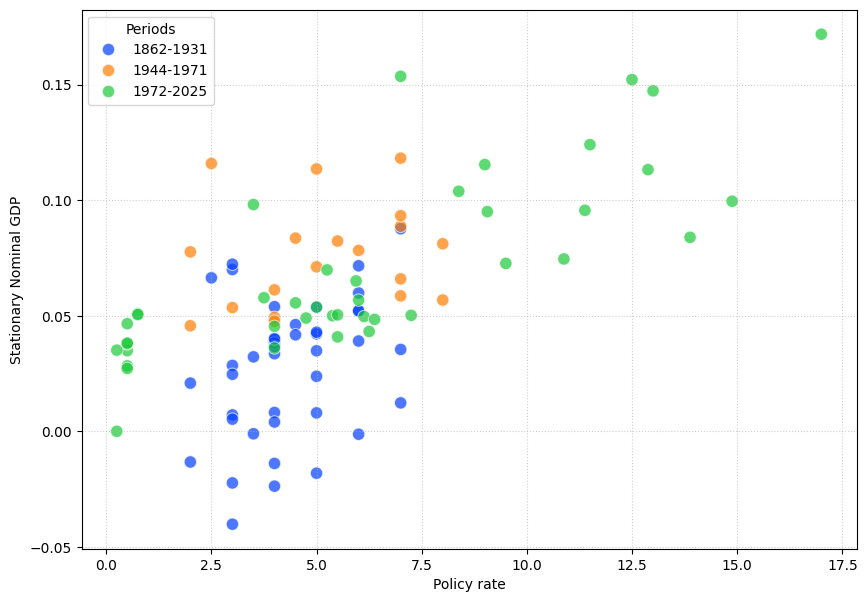

In [21]:
scat_period(
    df_det, 
    x="taux_directeur", 
    y="gdp_nominal_stat", 
    xlabel="Policy rate", 
    ylabel="Stationary Nominal GDP"
)



Ce graphique est plutôt rassurant, il montre qu'il y a une corrélation entre le taux directeur et le PIB nominal stationarisé. Cela montre que la corrélation entre les deux variables n'est pas seulement due à une certaine tendance et que nous allons pouvoir utiliser cette corrélation dans nos modèles. 

### Interest rate and exchange rate

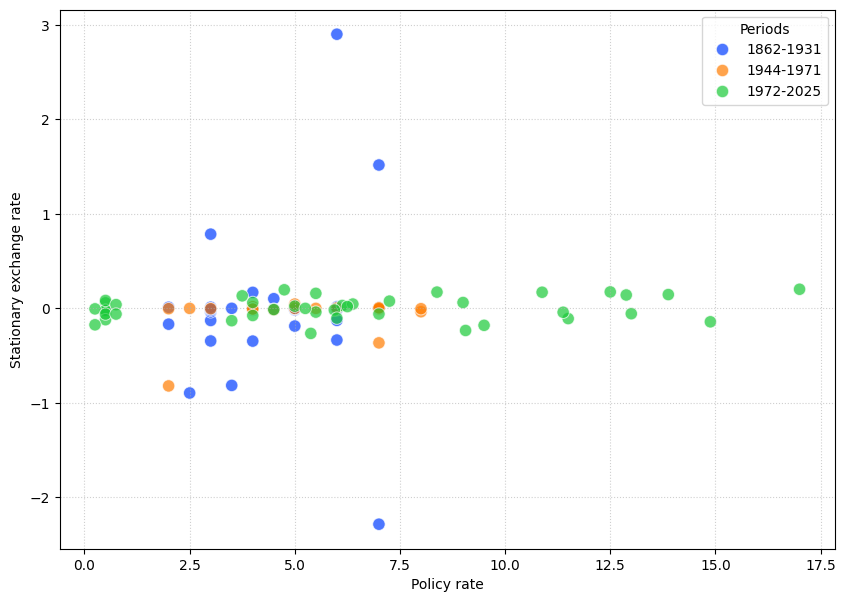

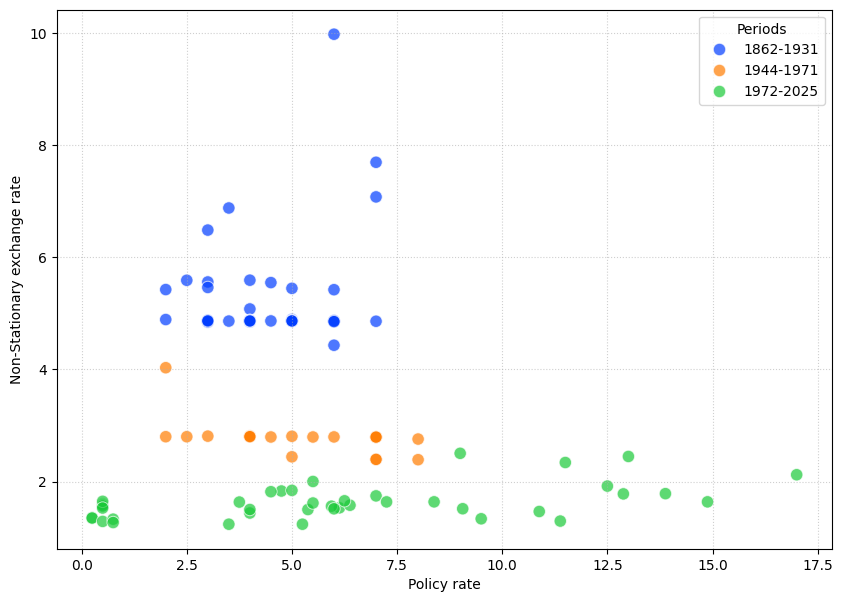

In [22]:
scat_period(df_det, x="taux_directeur", y="taux_changes_stat", xlabel = 'Policy rate', ylabel = 'Stationary exchange rate')
scat_period(df_det, x="taux_directeur", y="taux_changes", xlabel = 'Policy rate', ylabel = 'Non-Stationary exchange rate')

Ici on peut comparer la relation entre le taux directeur et le taux de change (stationnarisé ou non). On peut voir que la corrélation est quasiment nulle lorsque le taux de change est stationnarisé et que la corrélation n'est pas évidente non plus sans stationnarisation. Cette corrélation est donc à vérifier, peut être à confirmer avec de possibles lags. 

### Interest rate and inflation

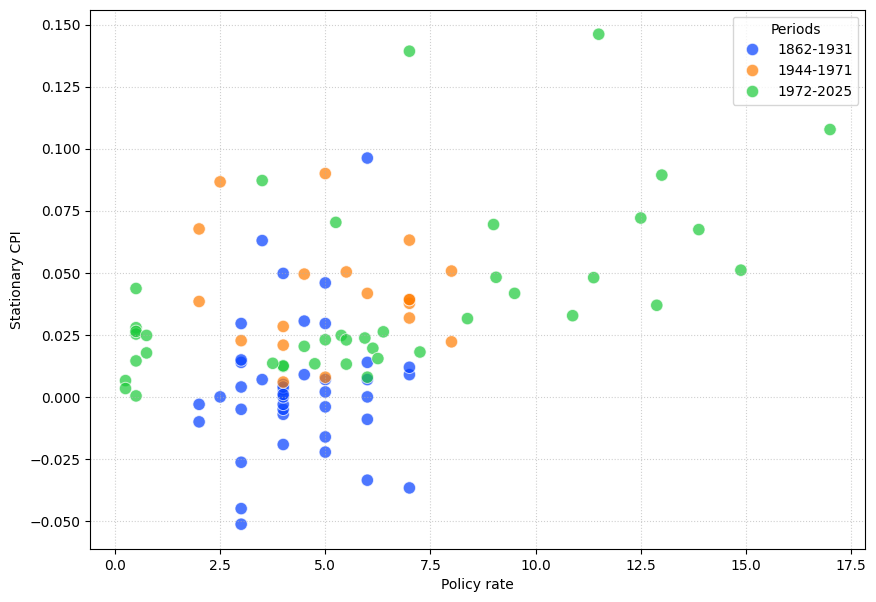

In [23]:
scat_period(df_det, x="taux_directeur", y="cpi_stat", xlabel = 'Policy rate', ylabel = 'Stationary CPI')

De la même manière que le premier graphique multivarié, cette relation est rassurante, malgré la correction pour tendance de l'inflation, la relation entre taux directeur et cpi semble rester valide et donc utilisable dans notre étude. 

### HeatMap 

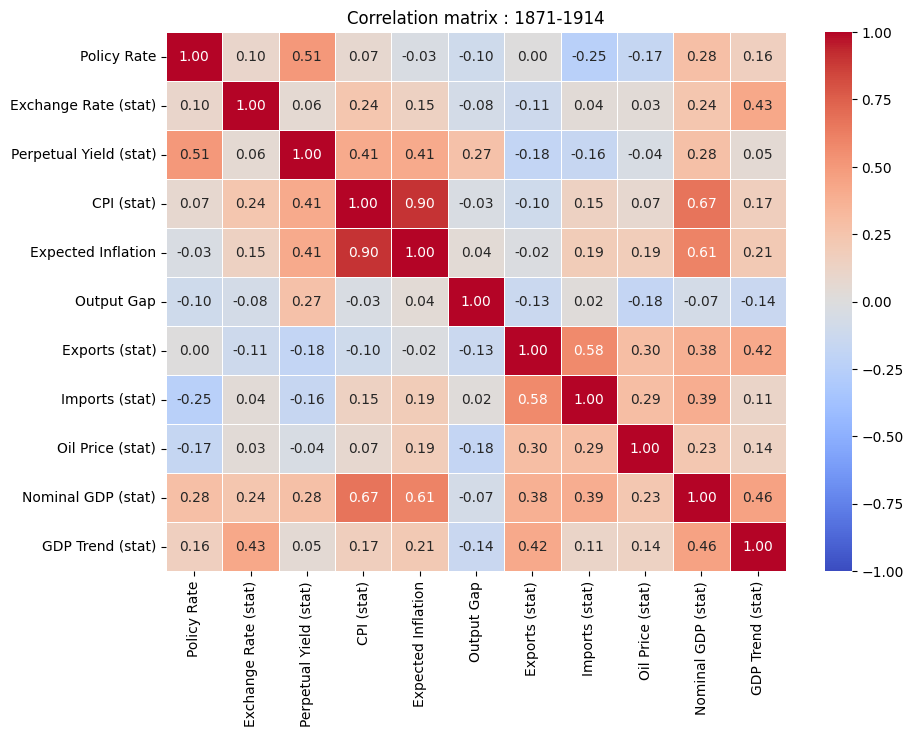

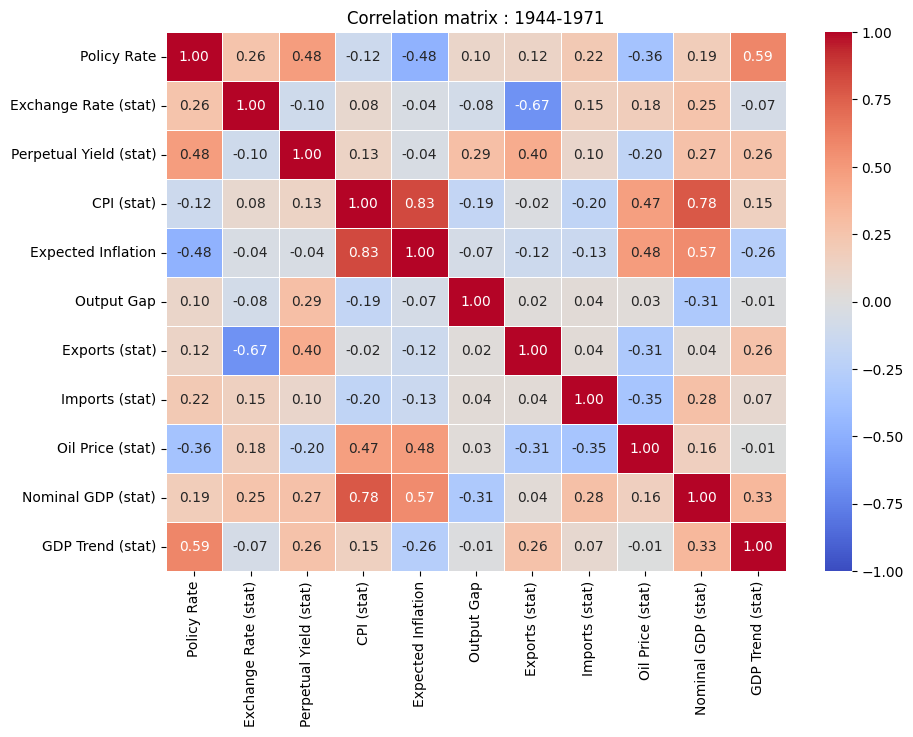

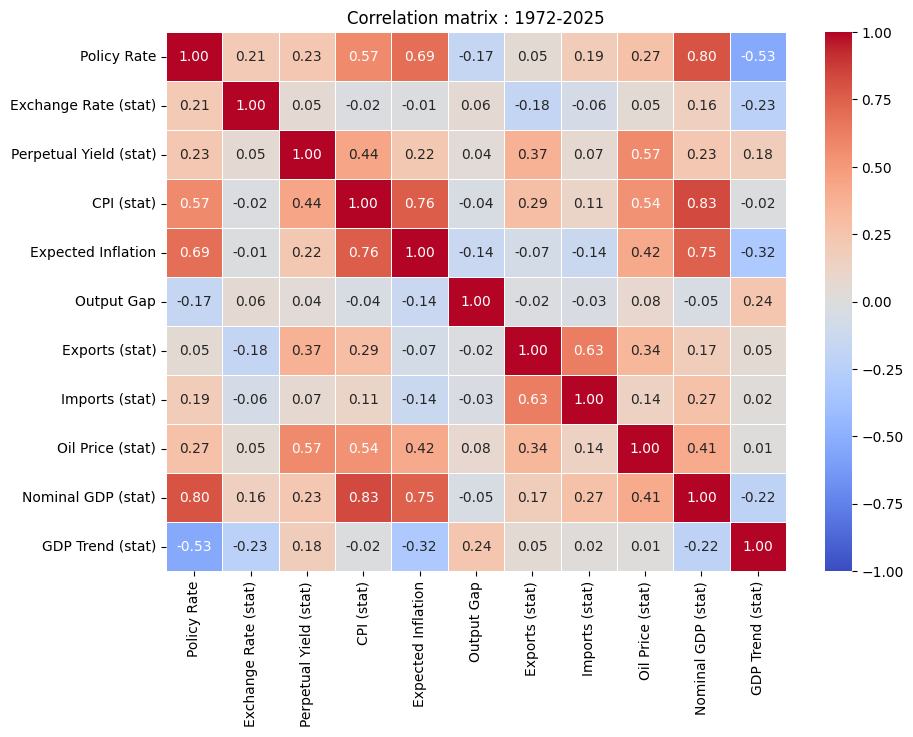

In [24]:
labels_mapping = {
    'taux_directeur': 'Policy Rate',
    'taux_changes_stat': 'Exchange Rate (stat)',
    'yield_perpetual_stat': 'Perpetual Yield (stat)',
    'cpi_stat': 'CPI (stat)',
    'expected_inflation': 'Expected Inflation',
    'output_gap': 'Output Gap',
    'export_stat': 'Exports (stat)',
    'import_stat': 'Imports (stat)',
    'oil_price_stat': 'Oil Price (stat)',
    'gdp_nominal_stat': 'Nominal GDP (stat)',
    'gdp_trend_stat_stat': 'GDP Trend (stat)'
}

cols_selection = ['year',
    'taux_directeur', 
    'taux_changes_stat', 
    'yield_perpetual_stat', 
    'cpi_stat', 
    'expected_inflation',
    'output_gap',
    'export_stat',
    'import_stat', 
    'oil_price_stat', 
    'gdp_nominal_stat', 
    'gdp_trend_stat_stat'
]

corr_matrix(df_det[cols_selection].rename(columns=labels_mapping))

Plusieurs relations interéssantes sont à tirer de ces heatmaps : 

1. La relation entre le taux directeur et l'inflation anticipée varie énormément selon les périodes. Sous l'étalon or, on peut croire que la banque centrale ne se souciait pas de l'inflation attendue mais gérait simplement ses réserves d'or. Cela peut être également lié au fait que sous l'étalon or, les gens pouvaient plus facilement prédire les faires de la banque centrale puisque sa politique monétaire était contrainte par l'étalon or. Dans la période 1944-1971, on peut penser que la BC stimulait la croissance économique sans se soucier de l'inflation attendue (ce qui ferait du sens avec la période de croissance d'après guerre). Dans la trosième période cependant, on voit que la BC à l'air de suivre une règle précise (Taylor peut-être ?) qui fait augmenter les taux quand l'inflation attendue est élevée. 

1. La relation entre le taux directeur et le GDP nominal peut montrer que l'on est passé d'une ère stable à une ère de "réaction" : la BC monte ses taux quand l'économie est en surchauffe. Il faudra faire attention à cette relation (laggée) probablement car les taux doivent en théorie freiner l'économie (peut-être à long terme).

1. Dans la première période l'inflation anticipée et l'inflation réelle sont quasiment parfaitement corrélées. Cela montre l'extrème stabilité de l'étalon or par son pouvoir de restriction de politique monétaire. Ensuite, la relation est toujours relativement significative mais se réduit tout de même.

Pour ce qui est de la multicolinéarité, il semble que nos variables soient correctement décoréllée au temps t. Cependant il faudra faire attention à ne pas inclure des variables de contrôles trop fortemment corrélées entre elles dans nos modèles afin d'éviter le problème de colinéarité. 

### Lagged HeatMap (important)

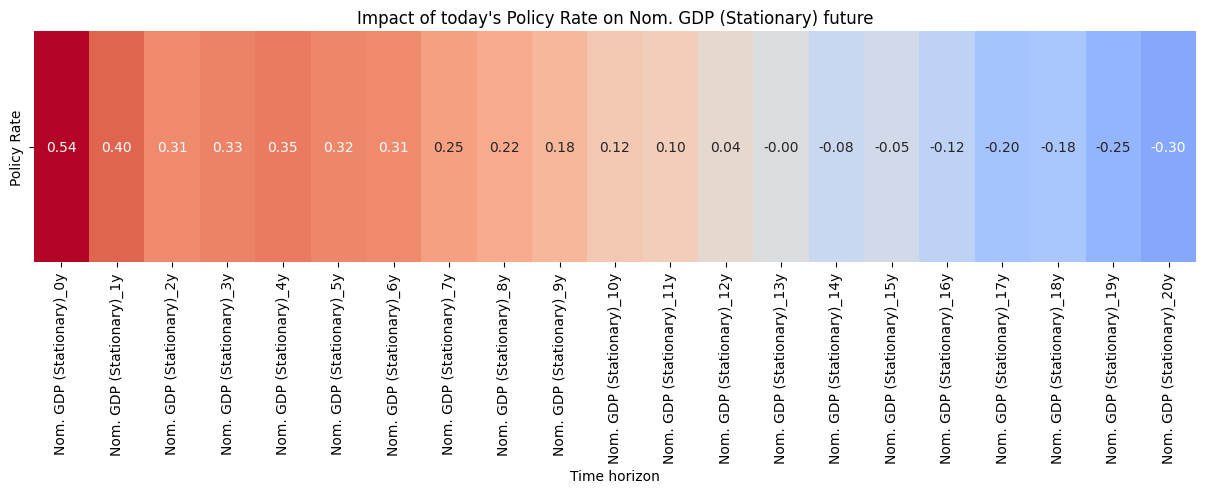

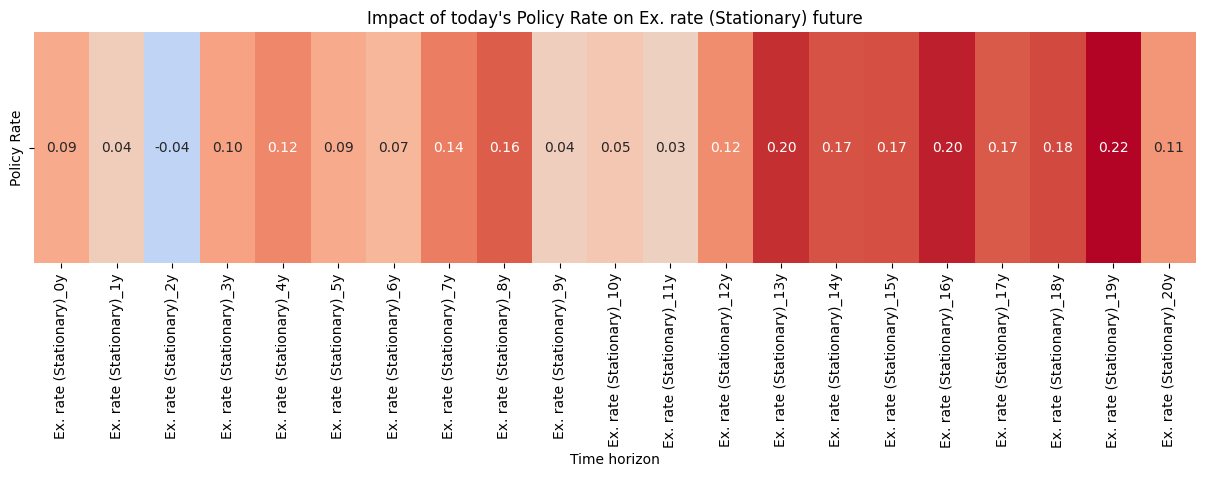

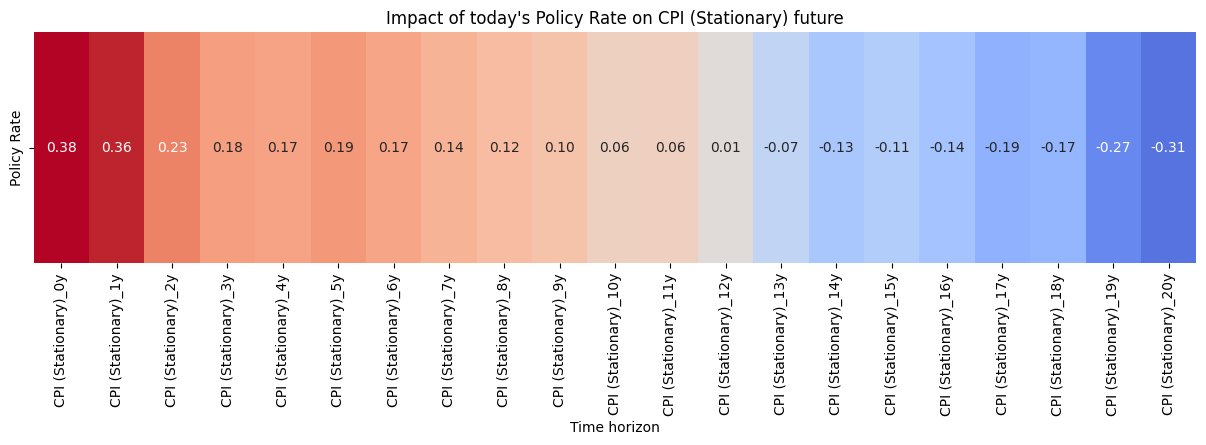

In [25]:
mapping = {
    'taux_directeur': 'Policy Rate',
    'gdp_nominal_stat': 'Nom. GDP (Stationary)',
    'taux_changes_stat': 'Ex. rate (Stationary)',
    'cpi_stat': 'CPI (Stationary)'
}

df_plt = df_det.rename(columns=mapping)

# Appels avec les nouveaux noms
plot_future_impact_heatmap(df_plt, mapping['taux_directeur'], mapping['gdp_nominal_stat'], 20)
plot_future_impact_heatmap(df_plt, mapping['taux_directeur'], mapping['taux_changes_stat'], 20)
plot_future_impact_heatmap(df_plt, mapping['taux_directeur'], mapping['cpi_stat'], 20)

Le premier et le trosième graphiques semblent très intéressant. 

Pour le premier, l'on peut constater que le taux directeur à l'air de s'ajuster à une surchauffe de l'économie. Ensuite, l'économie ralenti jusqu'à encore plus de 30 ans après. Cela pourrait montrer l'inertie réelle de l'économie (et donc la difficulté à capter l'effet réel du taux d'intérêt sur le PIB).

Pour le deuxième graphique, la tendance est exactement similaire. Le taux d'intérêt est d'abord corrélé à l'inflation (ce qui pourrait s'expliquer par la réaction de la BC) puis est ensuite négativement corrélé à celle-ci montrant potentiellement son effet à très long terme. 

Le taux de change à l'air de suivre une tendence plus hétérogène. 

Il faudra prendre ces horizons temporels en compte lors de notre analyse.

## Etude des chocs

<span style="color:red">**Cette section nous permettra de juger différents chocs au sein de notre échantillon afin de prendre une décision sur la possibilité de les enlever de notre analyse.**</span>

Ce que font ces graphiques : pour chaque année il calcule la corrélation moyenne entre les deux variables sur le span de temps chosis. Cela permet de remarquer les chocs structurels et les changement de relation entre les deux variables. Plus la fenètre est large, plus le graphique est stable mais peu précis, plus la fenêtre est petite, plus elle est précise mais également très bruitée. Cela nous permet d'identifier les chocs structurels et exceptionnel que l'on pourrait enlever de notre échantillon pour ne pas biaser l'analyse. 

In [27]:
mapping = {
    'taux_directeur': 'Policy Rate',
    'cpi': 'CPI',
    'taux_changes': 'Exchange Rate',
    'gdp_nominal': 'Nominal GDP'
}

df_plt = df.rename(columns=mapping)

y = ['cpi', 'taux_changes', 'gdp_nominal']
y_clean = [mapping[col] for col in y]

plot_rolling_corr(df_plt, mapping['taux_directeur'], y_clean, window=20)

Ici, l'analyse visuelle nous permet de voir les principaux points d'inflexions (qui sont par ailleurs souvent communs) et qui permettent d'identifier les variables à potentiellement omettre durant notre analyse afin de ne pas polluer notre analyse. Ces périodes "suspectes" sont d'après moi les suivantes :

1. 1882 à 1885 
1. 1928 à 1931 (crise de 29)
1. 1936 à 1937 (deux points d'inflexion)
1. 1948 à 1950 (après-guerre)
1. 1980 à 1987 (crise du pétrole)
1. 2022 à 2025 (covid)

Il faut rajouter à cela les deux périodes de guerre à savoir :

1. 1914 à 1918 (WW1)
1. 1939 à 1945 (WW2)

L'analyse restant relativement subjective, chacun pourra s'aider du graphique et des notes mentionnées pour faire ces modèles, l'idée n'est pas du tout de respecter les périodes identifiées à la lettre mais qu'elles vous donne des inspirations et vous facilitent le travail. 

Selon moi, il ne faudra pas enlever toutes ces dates d'office (car certaines périodes peuvent être intéressantes pour notre étude surtout quand elles sont longues) mais de comparer les résultats de nos modèles avec ce graph afin d'observer si les résultats que l'on obtient sont vraiment dûs aux régimes de taux de change ou à des chocs éxogène que l'on peut identifier grâce à ce graphique.